In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

methbac = pd.read_csv(r'methanobacterium_distances.tsv', sep='\t', header=None)
methsae = pd.read_csv(r'methanosaeta_20250902_dist.tsv', sep='\t', header=None)
cox = pd.read_csv(r'cox_distances.tsv', sep='\t', header=None)
syn = pd.read_csv(r'syntro_20250902_dist.tsv', sep='\t', header=None)

pix = 201
scale_um = 10

print(methbac.head)

<bound method NDFrame.head of                                           0           1
0     individual_object_140052330406736.ply   38.639358
1     individual_object_140052545762960.ply   45.149840
2     individual_object_140052330404944.ply   31.160873
3     individual_object_140052330380624.ply   14.711016
4     individual_object_140052330401872.ply   27.147744
...                                     ...         ...
2965  individual_object_140052325079824.ply  226.037607
2966  individual_object_140052322539536.ply  258.880923
2967  individual_object_140052322477840.ply  261.229784
2968  individual_object_140052322574608.ply  255.886046
2969  individual_object_140052322850000.ply  263.941281

[2970 rows x 2 columns]>


In [3]:
# convert pix to um
scale_conversion = scale_um/pix

methbac['um'] = methbac[1] * scale_conversion
methsae['um'] = methsae[1] * scale_conversion
cox['um'] = cox[1] * scale_conversion
syn['um'] = syn[1] * scale_conversion

print(methbac)

                                          0           1         um
0     individual_object_140052330406736.ply   38.639358   1.922356
1     individual_object_140052545762960.ply   45.149840   2.246261
2     individual_object_140052330404944.ply   31.160873   1.550292
3     individual_object_140052330380624.ply   14.711016   0.731891
4     individual_object_140052330401872.ply   27.147744   1.350634
...                                     ...         ...        ...
2965  individual_object_140052325079824.ply  226.037607  11.245652
2966  individual_object_140052322539536.ply  258.880923  12.879648
2967  individual_object_140052322477840.ply  261.229784  12.996507
2968  individual_object_140052322574608.ply  255.886046  12.730649
2969  individual_object_140052322850000.ply  263.941281  13.131407

[2970 rows x 3 columns]


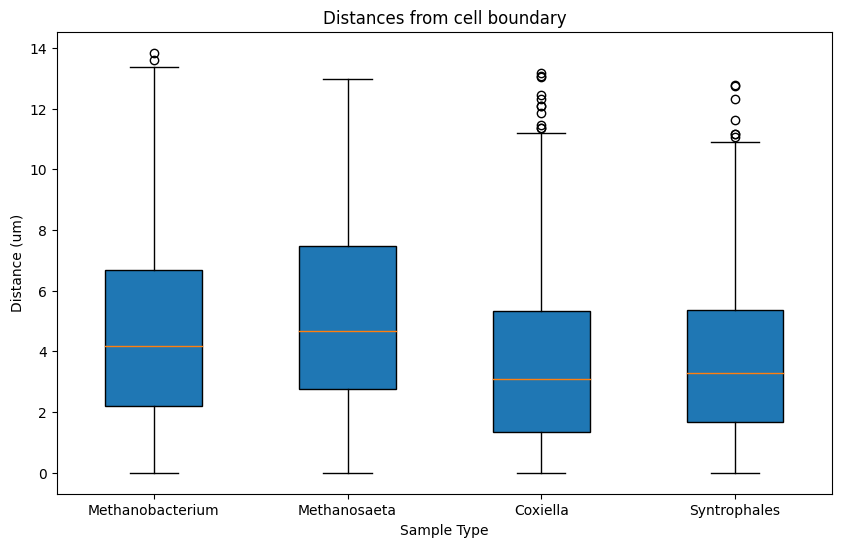

In [42]:
plt.figure(figsize=(10, 6))
plt.boxplot(methbac['um'], positions=[1], widths=0.5, patch_artist=True)
plt.boxplot(methsae['um'], positions=[2], widths=0.5, patch_artist=True)
plt.boxplot(cox['um'], positions=[3], widths=0.5, patch_artist=True)
plt.boxplot(syn['um'], positions=[4], widths=0.5, patch_artist=True)
plt.xticks([1, 2, 3, 4], ['Methanobacterium', 'Methanosaeta', 'Coxiella', 'Syntrophales'])
plt.xlabel('Sample Type')
plt.ylabel('Distance (um)')
plt.title('Distances from cell boundary')
save_path = 'distance_boxplot.svg'
plt.savefig(save_path, dpi=300)
plt.show()

In [43]:
# export df

pd.DataFrame({
    'Methanobacterium': methbac['um'],
    'Methanosaeta': methsae['um'],
    'Coxiella': cox['um'],
    'Syntrophales': syn['um']
}).to_csv('converted_data_um.csv', index=False)


Calculate symbiont - symbiont distances

In [4]:
cox_V_methabac = pd.read_csv(r'cox_dist_frm_methanobacterium.txt', sep='\t', header=None)
cox_V_methasae = pd.read_csv(r'cox_dist_frm_methanosaeta.txt', sep='\t', header=None)
cox_V_syntro = pd.read_csv(r'cox_dist_frm_syntro.txt', sep='\t', header=None)

methbac_V_methsae = pd.read_csv(r'methanobacterium_dist_frm_methanosaeta.txt', sep='\t', header=None)
methbac_V_syntro = pd.read_csv(r'methanobacterium_dist_frm_syntro.txt', sep='\t', header=None)
methbac_V_cox = pd.read_csv(r'methanobacterium_dist_frm_cox.txt', sep='\t', header=None) 

methsae_V_syntro = pd.read_csv(r'methanosaeta_dist_frm_syntro.txt', sep='\t', header=None)
methsae_V_cox = pd.read_csv(r'methanosaeta_dist_frm_cox.txt', sep='\t', header=None)
methsae_V_methabac = pd.read_csv(r'methanosaeta_dist_frm_methanobacterium.txt', sep='\t', header=None)

syn_V_cox = pd.read_csv(r'syntro_dist_frm_cox.txt', sep='\t', header=None)
syn_V_methabac = pd.read_csv(r'syntro_dist_frm_methanobacterium.txt', sep='\t', header=None)
syn_V_methsae = pd.read_csv(r'syntro_dist_frm_methanosaeta.txt', sep='\t', header=None)

pix = 201
scale_um = 10

print(cox_V_methabac.head())

                                       0          1
0  individual_object_140052545762960.ply   2.202709
1  individual_object_140052330380624.ply  25.109812
2  individual_object_140052330398800.ply  15.073844
3  individual_object_140052330400336.ply  21.212844
4  individual_object_140052330401872.ply   7.483315


In [5]:
# convert pix to um
scale_conversion = scale_um/pix
cox_V_methabac['um'] = cox_V_methabac[1] * scale_conversion
cox_V_methasae['um'] = cox_V_methasae[1] * scale_conversion
cox_V_syntro['um'] = cox_V_syntro[1] * scale_conversion
methbac_V_methsae['um'] = methbac_V_methsae[1] * scale_conversion
methbac_V_syntro['um'] = methbac_V_syntro[1] * scale_conversion
methbac_V_cox['um'] = methbac_V_cox[1] * scale_conversion
methsae_V_syntro['um'] = methsae_V_syntro[1] * scale_conversion
methsae_V_cox['um'] = methsae_V_cox[1] * scale_conversion
methsae_V_methabac['um'] = methsae_V_methabac[1] * scale_conversion
syn_V_cox['um'] = syn_V_cox[1] * scale_conversion
syn_V_methabac['um'] = syn_V_methabac[1] * scale_conversion
syn_V_methsae['um'] = syn_V_methsae[1] * scale_conversion

print(cox_V_methabac.head())

                                       0          1        um
0  individual_object_140052545762960.ply   2.202709  0.109588
1  individual_object_140052330380624.ply  25.109812  1.249244
2  individual_object_140052330398800.ply  15.073844  0.749943
3  individual_object_140052330400336.ply  21.212844  1.055365
4  individual_object_140052330401872.ply   7.483315  0.372304


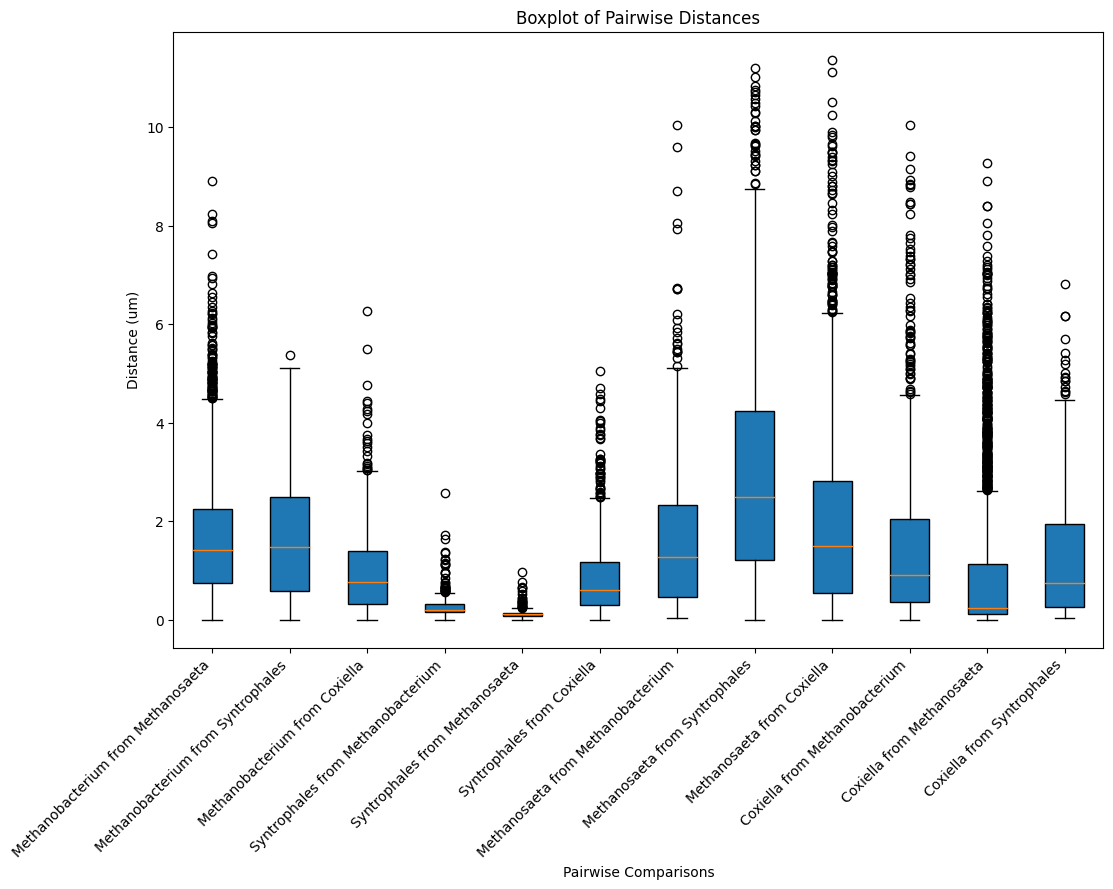

In [ ]:
# plot boxplots for all pairwise comparisons
plt.figure(figsize=(12, 8))
positions = range(1, 13)
plt.boxplot(methbac_V_methsae['um'], positions=[4], widths=0.5, patch_artist=True)
plt.boxplot(methbac_V_syntro['um'], positions=[5], widths=0.5, patch_artist=True)
plt.boxplot(methbac_V_cox['um'], positions=[6], widths=0.5, patch_artist=True)
plt.boxplot(syn_V_methabac['um'], positions=[11], widths=0.5, patch_artist=True)
plt.boxplot(syn_V_methsae['um'], positions=[12], widths=0.5, patch_artist=True)
plt.boxplot(syn_V_cox['um'], positions=[10], widths=0.5, patch_artist=True)
plt.boxplot(methsae_V_methabac['um'], positions=[9], widths=0.5, patch_artist=True)
plt.boxplot(methsae_V_syntro['um'], positions=[7], widths=0.5, patch_artist=True)
plt.boxplot(methsae_V_cox['um'], positions=[8], widths=0.5, patch_artist=True)
plt.boxplot(cox_V_methabac['um'], positions=[1], widths=0.5, patch_artist=True)
plt.boxplot(cox_V_methasae['um'], positions=[2], widths=0.5, patch_artist=True)
plt.boxplot(cox_V_syntro['um'], positions=[3], widths=0.5, patch_artist=True)
plt.xticks(positions, ['Methanobacterium from Methanosaeta', 'Methanobacterium from Syntrophales', 'Methanobacterium from Coxiella',
                       'Syntrophales from Methanobacterium', 'Syntrophales from Methanosaeta', 'Syntrophales from Coxiella',
                       'Methanosaeta from Methanobacterium','Methanosaeta from Syntrophales', 'Methanosaeta from Coxiella', 
                       'Coxiella from Methanobacterium', 'Coxiella from Methanosaeta', 'Coxiella from Syntrophales'], rotation=45, ha='right')
plt.xlabel('Pairwise Comparisons')
plt.ylabel('Distance (um)')
plt.title('Boxplot of Pairwise Distances')
save_path = 'pairwise_sym_dist_boxplot.svg'
#plt.savefig(save_path, dpi=300)
plt.show()

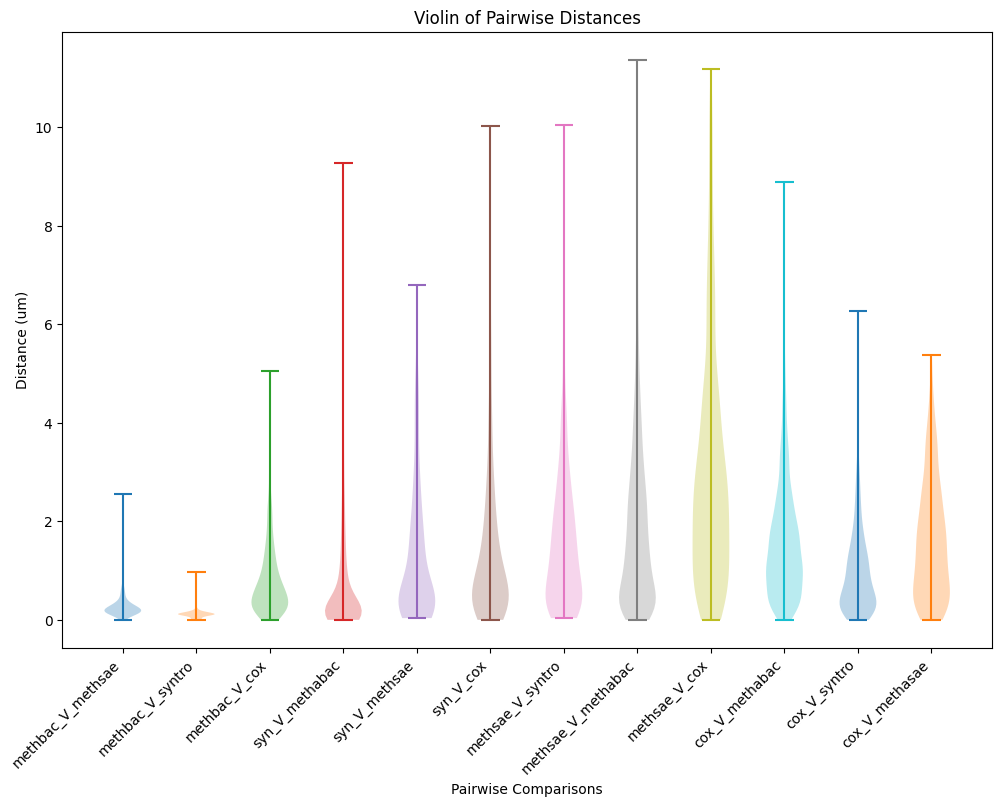

In [13]:
# plot violin plot for all pairwise comparisons
plt.figure(figsize=(12, 8))
positions = range(1, 13)
plt.violinplot(methbac_V_methsae['um'], positions=[1], widths=0.5)
plt.violinplot(methbac_V_syntro['um'], positions=[2], widths=0.5)
plt.violinplot(methbac_V_cox['um'], positions=[3], widths=0.5)
plt.violinplot(syn_V_methabac['um'], positions=[4], widths=0.5)
plt.violinplot(syn_V_methsae['um'], positions=[5], widths=0.5)
plt.violinplot(syn_V_cox['um'], positions=[6], widths=0.5)
plt.violinplot(methsae_V_syntro['um'], positions=[7], widths=0.5)
plt.violinplot(methsae_V_methabac['um'], positions=[8], widths=0.5)
plt.violinplot(methsae_V_cox['um'], positions=[9], widths=0.5)
plt.violinplot(cox_V_methabac['um'], positions=[10], widths=0.5)
plt.violinplot(cox_V_syntro['um'], positions=[11], widths=0.5)
plt.violinplot(cox_V_methasae['um'], positions=[12], widths=0.5)
plt.xticks(positions, ['methbac_V_methsae', 'methbac_V_syntro', 'methbac_V_cox',
                       'syn_V_methabac', 'syn_V_methsae', 'syn_V_cox',
                       'methsae_V_syntro','methsae_V_methabac', 'methsae_V_cox', 
                       'cox_V_methabac', 'cox_V_syntro', 'cox_V_methasae'], rotation=45, ha='right')
plt.xlabel('Pairwise Comparisons')
plt.ylabel('Distance (um)')
plt.title('Violin of Pairwise Distances')
save_path = 'pairwise_sym_dist_violinplot.svg'
plt.savefig(save_path, dpi=300)
plt.show()

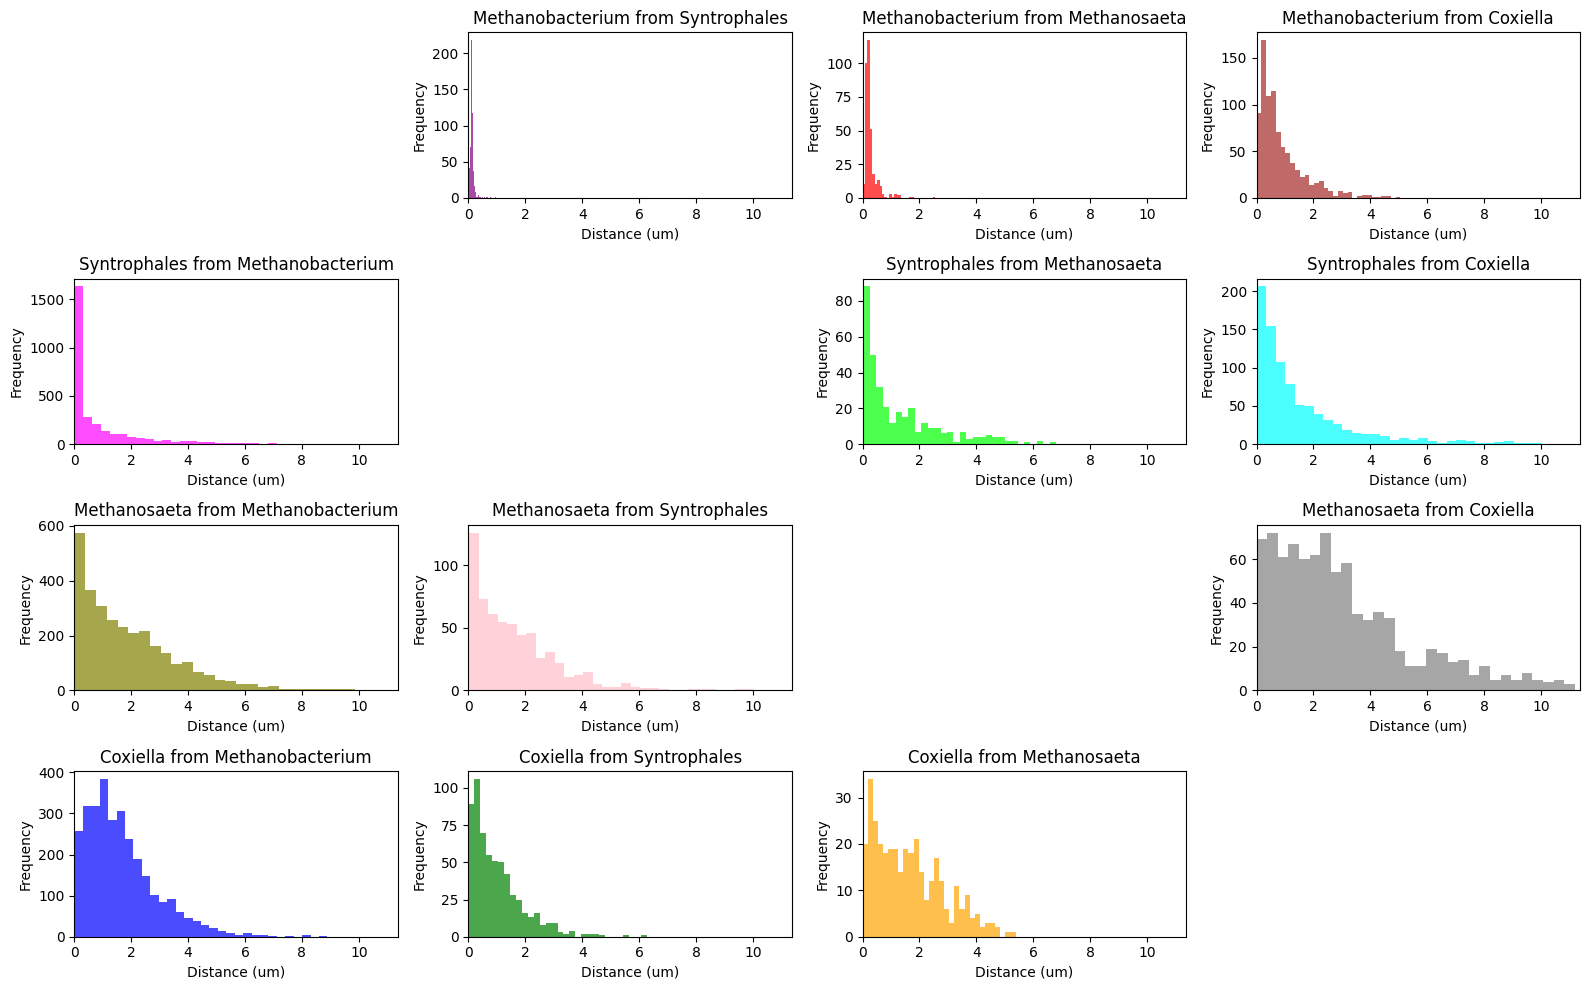

In [ ]:
# Find global min and max for 'um'
all_um = [
    cox_V_methabac['um'], cox_V_methasae['um'], cox_V_syntro['um'],
    methbac_V_methsae['um'], methbac_V_syntro['um'], methbac_V_cox['um'],
    methsae_V_syntro['um'], methsae_V_cox['um'], methsae_V_methabac['um'],
    syn_V_cox['um'], syn_V_methabac['um'], syn_V_methsae['um']
]
xmin = min(um.min() for um in all_um)
xmax = max(um.max() for um in all_um)

plt.figure(figsize=(16, 10))
for i, (um, title, color) in enumerate([
    ([], ' ', 'navy'),
    (methbac_V_syntro['um'], 'Methanobacterium from Syntrophales', 'purple'),
    (methbac_V_methsae['um'], 'Methanobacterium from Methanosaeta', 'red'),
    (methbac_V_cox['um'], 'Methanobacterium from Coxiella', 'brown'),
    (syn_V_methabac['um'], 'Syntrophales from Methanobacterium', 'magenta'),
    ([], ' ', 'darkmagenta'),
    (syn_V_methsae['um'], 'Syntrophales from Methanosaeta', 'lime'),
    (syn_V_cox['um'], 'Syntrophales from Coxiella', 'cyan'),
    (methsae_V_methabac['um'], 'Methanosaeta from Methanobacterium', 'olive'),
    (methsae_V_syntro['um'], 'Methanosaeta from Syntrophales', 'pink'),
    ([], ' ', 'darkorange'),
    (methsae_V_cox['um'], 'Methanosaeta from Coxiella', 'gray'),
    (cox_V_methabac['um'], 'Coxiella from Methanobacterium', 'blue'),
    (cox_V_syntro['um'], 'Coxiella from Syntrophales', 'green'),
    (cox_V_methasae['um'], 'Coxiella from Methanosaeta', 'orange'),
    ([], ' ', 'darkgreen')
]):
    plt.subplot(4, 4, i+1)
    if len(um) == 0:
        plt.axis('off')
    else:
        plt.hist(um, bins=30, color=color, alpha=0.7)
        plt.title(title)
        plt.xlabel('Distance (um)')
        plt.ylabel('Frequency')
        plt.xlim(xmin, xmax)
plt.tight_layout()
#save_path = 'pairwise_sym_dist_histograms.svg'
plt.savefig(save_path, dpi=300)
plt.show()
